# Methods to clean data

In [159]:
import pandas as pd
df_missing_data = pd.read_csv("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/company_financials.csv") # path of office pc
# df_missing_data = pd.read_csv("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/company_financials.csv") # path of macbook 
df_missing_data

,tickers,eps,revenue,price,people
0,Apple,NaN,105.55,113.42,Tim Cook
1,Microsoft,1.59,-42.45,410.99,Satya Nadella
2,Google,3.94,118.78,83.55,Sundar Pichai
3,Amazon,NaN,69.97,494.10,Andy Jassy
4,Facebook,1.3,85.42,397.51,Mark Zuckerberg
5,Tesla,1.3,-69.91,139.42,Elon Musk
6,Netflix,6.74,192.61,52.48,Reed Hastings
7,Intel,n.a.,99.33,416.96,Pat Gelsinger
8,IBM,0.59,47.11,368.09,n.a.
9,Samsung,3.63,141.13,378.05,Jong-Hee Han


### Here in this dataFrame we can see that the data is a bit messy
- In people and eps columns we have a value n.a.
- In revenue column we have 2 values that are in negative
### We need to clean this mess before we start our analysis
- We need to replace the n.a. with NaN
- We need to replace the -ve values in revenue columns as well because any company's revenue cannot be -ve it will either be zero or less than zero.

## Remove n.a. values when creating dataFrame from a csv file

In [160]:
#path of pc
df_cleaned = pd.read_csv("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/company_financials.csv",na_values=["not available","n.a."])
# path of macbook
# df_cleaned = pd.read_csv("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/company_financials.csv",na_values=["not available","n.a."])
df_cleaned

,tickers,eps,revenue,price,people
0,Apple,NaN,105.55,113.42,Tim Cook
1,Microsoft,1.59,-42.45,410.99,Satya Nadella
2,Google,3.94,118.78,83.55,Sundar Pichai
3,Amazon,NaN,69.97,494.10,Andy Jassy
4,Facebook,1.30,85.42,397.51,Mark Zuckerberg
5,Tesla,1.30,-69.91,139.42,Elon Musk
6,Netflix,6.74,192.61,52.48,Reed Hastings
7,Intel,NaN,99.33,416.96,Pat Gelsinger
8,IBM,0.59,47.11,368.09,NaN
9,Samsung,3.63,141.13,378.05,Jong-Hee Han


#### As you can see all the n.a. values have been replaced with NaN values 

## Now lets see how we can remove -ve values from the revenue column

In [161]:
import numpy as np
df_cleaned.loc[df_cleaned["revenue"]<0, "revenue"] = np.nan
df_cleaned

,tickers,eps,revenue,price,people
0,Apple,NaN,105.55,113.42,Tim Cook
1,Microsoft,1.59,NaN,410.99,Satya Nadella
2,Google,3.94,118.78,83.55,Sundar Pichai
3,Amazon,NaN,69.97,494.10,Andy Jassy
4,Facebook,1.30,85.42,397.51,Mark Zuckerberg
5,Tesla,1.30,NaN,139.42,Elon Musk
6,Netflix,6.74,192.61,52.48,Reed Hastings
7,Intel,NaN,99.33,416.96,Pat Gelsinger
8,IBM,0.59,47.11,368.09,NaN
9,Samsung,3.63,141.13,378.05,Jong-Hee Han


### Explanation 
#### .loc[]
- It is label-based indexing. It is used to access a group of rows and columns in a DataFrame by their labels (names) --- not by their integer positions.
- syntax : ```df.loc[row_condition, column_label]```
  - row_condition: A condition or label(s) that tells pandas which rows you want.
  - column_label: The column(s) you want from those selected rows.

## How to replace NaN value in a cell in a dataFrame if a value is known manually
#### Now in the people column we can see that IBM has a NAN value. 
I know that the ceo of IBM is Arvind Krishna and I want to replace the NaN with the actual ceo name in the people column of the dataFrame

In [162]:
df_cleaned.loc[8,"people"] = "Arvind Krishna"
df_cleaned

,tickers,eps,revenue,price,people
0,Apple,NaN,105.55,113.42,Tim Cook
1,Microsoft,1.59,NaN,410.99,Satya Nadella
2,Google,3.94,118.78,83.55,Sundar Pichai
3,Amazon,NaN,69.97,494.10,Andy Jassy
4,Facebook,1.30,85.42,397.51,Mark Zuckerberg
5,Tesla,1.30,NaN,139.42,Elon Musk
6,Netflix,6.74,192.61,52.48,Reed Hastings
7,Intel,NaN,99.33,416.96,Pat Gelsinger
8,IBM,0.59,47.11,368.09,Arvind Krishna
9,Samsung,3.63,141.13,378.05,Jong-Hee Han


### Explanation:
- df_cleaned.loc[8,"people"] = "Arvind Krishna" : Here 8 is the row number and "people" is the column name
- using these two we are locating the cell to be updated and assign a new value into it.

## Handle n.a. values using a Converter function

### There is another way to achieve the same result 
What if we replace n.a. value in the people column in the IBM row. But this can be dangerous because what I am about to do will take effect on the entire column.

In [163]:
# import csv and create a dataFrame
# conver that csv file into xcel sheet
# path of pc
df = pd.read_csv("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/company_financials.csv")
# path of macbook
# df = pd.read_csv("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/company_financials.csv")
df_cleaned.to_excel(excel_writer = "test_converter.xlsx", header = True, index=True, index_label = 'Index', startrow=0, startcol=0)

In [164]:
def people_col_converter(cell):
    if cell == "n.a.":
        return "Arvind Krishna"
    else:
        return cell
df_excel = pd.read_excel("test_converter.xlsx",engine="openpyxl",converters = {
     "people" : people_col_converter
})
df_excel

,Index,tickers,eps,revenue,price,people
0,0,Apple,NaN,105.55,113.42,Tim Cook
1,1,Microsoft,1.59,NaN,410.99,Satya Nadella
2,2,Google,3.94,118.78,83.55,Sundar Pichai
3,3,Amazon,NaN,69.97,494.10,Andy Jassy
4,4,Facebook,1.30,85.42,397.51,Mark Zuckerberg
5,5,Tesla,1.30,NaN,139.42,Elon Musk
6,6,Netflix,6.74,192.61,52.48,Reed Hastings
7,7,Intel,NaN,99.33,416.96,Pat Gelsinger
8,8,IBM,0.59,47.11,368.09,Arvind Krishna
9,9,Samsung,3.63,141.13,378.05,Jong-Hee Han


### Explanation:
- people_col_converter function will be called for every single cell in the people column.
- This function will called when creating dataFrame from the excel sheet present in the file system.

### Why this worked?
- The reason why this worked is because the ```people``` column only had one ```NaN``` value in the entire column.

### The reason to avoid this method 
- If there were multiple ```NaN``` values inside the ```people``` column then this method would have replaced all the ```NaN``` values with the value ```"Arvind Krishna"``` which ofcourse is not desirable in this case.

# How to handle missing data in pandas

In [165]:
# offcie pc path
df_missing_val = pd.read_csv("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_data_missing_values.csv")
# macbook path
# df_missing_val = pd.read_csv("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_data_missing_values.csv")
type(df_missing_val["date"][0])
df_missing_val

,date,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
0,2023-01-01,-2.9,87.4,11.9,Snow
1,2023-01-02,15.9,56.8,5.4,Snow
2,2023-01-03,22.8,48.7,11.3,NaN
3,2023-01-04,39.4,56.4,12.2,Rain
4,2023-01-05,7.8,82.9,7.1,Rain
...,...,...,...,...,...
95,2023-04-06,33.0,36.3,4.1,Fog
96,2023-04-07,-4.4,58.1,8.0,Fog
97,2023-04-08,11.8,41.2,13.0,Sunny
98,2023-04-09,14.7,44.4,NaN,Sunny


#### The column date can have date values in form of string so to be safe we are going to make sure that when we create the dataFrame from a csv file we convert those string values in the date column into a datetime timestamps.
- First we need to convert all the dates in the date column from type string to type date

In [166]:
# pc path
df_missing_val = pd.read_csv("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_data_missing_values.csv", parse_dates = ["date"])
# macbook path
# df_missing_val = pd.read_csv("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_data_missing_values.csv", parse_dates = ["date"])
type(df_missing_val["date"][0])

pandas._libs.tslibs.timestamps.Timestamp

In [167]:
df_missing_val

,date,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
0,2023-01-01,-2.9,87.4,11.9,Snow
1,2023-01-02,15.9,56.8,5.4,Snow
2,2023-01-03,22.8,48.7,11.3,NaN
3,2023-01-04,39.4,56.4,12.2,Rain
4,2023-01-05,7.8,82.9,7.1,Rain
...,...,...,...,...,...
95,2023-04-06,33.0,36.3,4.1,Fog
96,2023-04-07,-4.4,58.1,8.0,Fog
97,2023-04-08,11.8,41.2,13.0,Sunny
98,2023-04-09,14.7,44.4,NaN,Sunny


### Set the date column as an index of the dataFrame instead of the default index

In [168]:
df_missing_val.set_index("date",inplace=True)
df_missing_val

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,NaN
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
...,...,...,...,...
2023-04-06,33.0,36.3,4.1,Fog
2023-04-07,-4.4,58.1,8.0,Fog
2023-04-08,11.8,41.2,13.0,Sunny


## Find all the rows with the missing values in the dataFrame

In [169]:
df_missing_val[df_missing_val.isna().any(axis=1)]

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-03,22.8,48.7,11.3,NaN
2023-01-06,-1.5,12.9,Rain,NaN
2023-01-10,65.2,6.5,Sunny,NaN
2023-01-15,NaN,74.3,8.9,Snow
2023-01-21,18.9,5.5,NaN,NaN
2023-01-22,5.3,32.9,NaN,Rain
2023-01-31,58.3,Fog,NaN,NaN
2023-02-02,5.2,64.0,NaN,Fog
2023-02-04,-2.6,55.1,1.7,NaN


### Explanation:
df_missing_val.isna()

    Returns a DataFrame of the same shape where:

        True means the value is missing (NaN)

        False means it's not missing
        
.any(axis=1)

    This is a reduction operation that checks if any value in each row is True.

So what is axis=1?

    axis=1 → operate row-wise

    axis=0 → operate column-wise



### Topics covered 
- fillna to fill missing values using differenbt ways
- interpolate to make a guess on missing values using interpolation
- dropna to drop rows with missing values

### Fillna method to replace NaN values with Zeros in the dataFrame with missing values

In [170]:
new_df_fill_na = df_missing_val.fillna(0)
new_df_fill_na

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,0
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
...,...,...,...,...
2023-04-06,33.0,36.3,4.1,Fog
2023-04-07,-4.4,58.1,8.0,Fog
2023-04-08,11.8,41.2,13.0,Sunny


### Find all the rows that have zero in it in the dataFrame

In [171]:
new_df_fill_na[(new_df_fill_na==0).any(axis=1)]

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-03,22.8,48.7,11.3,0
2023-01-06,-1.5,12.9,Rain,0
2023-01-10,65.2,6.5,Sunny,0
2023-01-15,0.0,74.3,8.9,Snow
2023-01-21,18.9,5.5,0,0
2023-01-22,5.3,32.9,0,Rain
2023-01-31,58.3,Fog,0,0
2023-02-02,5.2,64.0,0,Fog
2023-02-04,-2.6,55.1,1.7,0


### Explanation : 
This method will fill the entire dataFrame with 0 where NaN values were present in the dataFrame

### Sometimes we may want to fillna but we don't want to fill the entire dataFrame with 0. May be we want to specify different values for different columns 

In [172]:
new_df = df_missing_val.fillna({
    "temperature_celsius":0,
    "humidity_percent":0,
    "wind_speed_kmph":0,
    "weather_condition":"no event"
})
new_df

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,no event
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
...,...,...,...,...
2023-04-06,33.0,36.3,4.1,Fog
2023-04-07,-4.4,58.1,8.0,Fog
2023-04-08,11.8,41.2,13.0,Sunny


#### Get all the rows where it has data that zero in the dataFrame

In [173]:
new_df[(new_df==0).any(axis=1)]

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-15,0.0,74.3,8.9,Snow
2023-01-21,18.9,5.5,0,no event
2023-01-22,5.3,32.9,0,Rain
2023-01-31,58.3,Fog,0,no event
2023-02-02,5.2,64.0,0,Fog
2023-02-06,0.0,64.4,8.7,Sunny
2023-02-20,19.4,0,13.2,Rain
2023-03-08,15.6,0,16.3,Rain
2023-03-13,12.7,59.3,0,no event


#### Get all the rows where it has data "no event"

In [174]:
new_df[(new_df=="no event").any(axis=1)]

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-03,22.8,48.7,11.3,no event
2023-01-06,-1.5,12.9,Rain,no event
2023-01-10,65.2,6.5,Sunny,no event
2023-01-21,18.9,5.5,0,no event
2023-01-31,58.3,Fog,0,no event
2023-02-04,-2.6,55.1,1.7,no event
2023-02-24,15.4,16.7,11.1,no event
2023-03-04,20.5,70.9,9.8,no event
2023-03-13,12.7,59.3,0,no event


#### We should avoid replacing NaN with zeros
- Reason : If we replace all the NaN values with 0 in columns temperature_celsius, humidity_percent and wind_speed_kmph. Then it will cause issues when we calculate mean in those columns.

#### Another way of getting between estimate is to carry forward the temperature of one row previous of the row where 0 is present.

In [175]:
previous_fill_val_df = df_missing_val.fillna(method="ffill")
previous_fill_val_df

/tmp/ipykernel_2713287/3941097953.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  previous_fill_val_df = df_missing_val.fillna(method="ffill")


,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,Snow
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
...,...,...,...,...
2023-04-06,33.0,36.3,4.1,Fog
2023-04-07,-4.4,58.1,8.0,Fog
2023-04-08,11.8,41.2,13.0,Sunny


### Explanation : 
/tmp/ipykernel_2951661/3941097953.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  previous_fill_val_df = df_missing_val.fillna(method="ffill")  
<br>
Means that using the method="ffill" or method="bfill" inside .fillna() is going to be removed in future versions of pandas.

In [176]:
df_missing_val

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,NaN
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
...,...,...,...,...
2023-04-06,33.0,36.3,4.1,Fog
2023-04-07,-4.4,58.1,8.0,Fog
2023-04-08,11.8,41.2,13.0,Sunny


In [177]:
previous_fill_val_df = df_missing_val.ffill()
previous_fill_val_df

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,Snow
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
...,...,...,...,...
2023-04-06,33.0,36.3,4.1,Fog
2023-04-07,-4.4,58.1,8.0,Fog
2023-04-08,11.8,41.2,13.0,Sunny


#### Check if there exist any NaN values in any of the rows in the dataFrame

In [178]:
previous_fill_val_df[previous_fill_val_df.isna().any(axis=1)]

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,


#### This confirms that our dataFrame infact has no NaN values in it

#### Another way of getting bettween estimate is to carry forward the temperature of one row next of the row where 0 is present.

In [179]:
df_missing_val

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,NaN
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
...,...,...,...,...
2023-04-06,33.0,36.3,4.1,Fog
2023-04-07,-4.4,58.1,8.0,Fog
2023-04-08,11.8,41.2,13.0,Sunny


In [180]:
next_fill_val_df = df_missing_val.bfill()
next_fill_val_df

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,Rain
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
...,...,...,...,...
2023-04-06,33.0,36.3,4.1,Fog
2023-04-07,-4.4,58.1,8.0,Fog
2023-04-08,11.8,41.2,13.0,Sunny


#### Lets confirm if there exist any NaN values in the dataFrame

In [181]:
next_fill_val_df[next_fill_val_df.isna().any(axis=1)]

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,


#### Again this confirms that there exists no NaN values in the dataFrame

#### How to limit the number of times a value is allowed to be copied in these two methods 
- Another way of getting between estimate is to carry forward the temperature of one row previous of the row where 0 is present.
- Another way of getting between estimate is to carry forward the temperature of one row next of the row where 0 is present.

In [182]:
df_missing_data.head(10)

,tickers,eps,revenue,price,people
0,Apple,NaN,105.55,113.42,Tim Cook
1,Microsoft,1.59,-42.45,410.99,Satya Nadella
2,Google,3.94,118.78,83.55,Sundar Pichai
3,Amazon,NaN,69.97,494.10,Andy Jassy
4,Facebook,1.3,85.42,397.51,Mark Zuckerberg
5,Tesla,1.3,-69.91,139.42,Elon Musk
6,Netflix,6.74,192.61,52.48,Reed Hastings
7,Intel,n.a.,99.33,416.96,Pat Gelsinger
8,IBM,0.59,47.11,368.09,n.a.
9,Samsung,3.63,141.13,378.05,Jong-Hee Han


#### Setting the limit to 1 
- Here in this case the value will only be allowed to be copied once

In [183]:
copy_once_df = df_missing_val.ffill(limit=1)
copy_once_df.head(10)

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,Snow
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
2023-01-06,-1.5,12.9,Rain,Rain
2023-01-07,20.4,67.0,7.0,Fog
2023-01-08,36.8,83.6,5.7,Cloudy
2023-01-09,7.5,79.0,9.4,Sunny


#### Lets check if this dataFrame has any NaN values in it

In [184]:
copy_once_df[copy_once_df.isna().any(axis=1)]

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-22,5.3,32.9,NaN,Rain
2023-03-24,NaN,63.3,5.7,Cloudy


## Clean data using Interpolation

#### Explanation as to why these methods are a bit restrictive in cases when you are dealing with the values such as temperature
Methods in question
- Another way of getting the estimate between two values is to carry forward the temperature of one row previous of the row where 0 is present.
- Another way of getting estimate between two values is to carry forward the temperature of one row next of the row where 0 is present.
<br>
Suppose there on the day 1 we have a temperature -2.9 degrees then on day 2 the df has a NaN value and on day 3 the df has 14 degree temperature
<br>
Case 1 : Another way of getting between estimate is to carry forward the temperature of one row previous of the row where 0 is present. <br>
day 1 --> -2.9 <br>
day 2 --> -2.9 <br>
day 3 --> 14 <br>
<br>
Case 2 : Another way of getting between estimate is to carry forward the temperature of one row next of the row where 0 is present. <br>
day 1 --> -2.9 <br>
day 2 --> 14 <br>
day 3 --> 14 <br>

In both the cases the temperature between days 1 to 3 doesn't rise gradually it raises abruptly and then the two consecutive days have the same temperature in real life that's not how it works the temperature rises normally and gradually. So how can we deal with the NaN values in the temperature column or in the dataFrame as a whole?

## What is interpolation ? 
```DataFrame.interpolation()``` is a pandas method used to fill in missing values NaN by estimating or guessing what the values should be, based on surrounding data. <br>
Here is the link to the docs related to this topic : https://pandas.pydata.org/docs/dev/reference/api/pandas.DataFrame.interpolate.html <br>
```DataFrame.interpolate(method='linear', *, axis=0, limit=None, inplace=False, limit_direction=None, limit_area=None, **kwargs)```
<br>

In [185]:
interpolated_val_df = df_missing_val.interpolate()
interpolated_val_df.head(10)

/tmp/ipykernel_2713287/1733039495.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  interpolated_val_df = df_missing_val.interpolate()


,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,NaN
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
2023-01-06,-1.5,12.9,Rain,NaN
2023-01-07,20.4,67.0,7.0,Fog
2023-01-08,36.8,83.6,5.7,Cloudy
2023-01-09,7.5,79.0,9.4,Sunny


### Explanation:
- DataFrame df_missing_val has columns with object dtype (e.g. strings or mixed types).
- interpolate() is meant for numeric columns, and using it on object-type columns is being deprecated.

In [186]:
interpolated_val_df = df_missing_val.select_dtypes(include=["number"]).interpolate()
interpolated_val_df.head(10)

,temperature_celsius
date,
2023-01-01,-2.9
2023-01-02,15.9
2023-01-03,22.8
2023-01-04,39.4
2023-01-05,7.8
2023-01-06,-1.5
2023-01-07,20.4
2023-01-08,36.8
2023-01-09,7.5


#### Why its giving me only temperature_celsius column as a result ? 
- Because only temperature is currently recognized as a numeric column (int or float) in the dataFrame
- Hence before I interpolate the dataFrame. I need to change these columns humidity_percent, wind_speed_kmph to numbers type columns so that interpolation can actually work 

In [90]:
df_missing_val.head(10)

,temperature_celsius,humidity_percent,wind_speed_kmph,weather_condition
date,,,,
2023-01-01,-2.9,87.4,11.9,Snow
2023-01-02,15.9,56.8,5.4,Snow
2023-01-03,22.8,48.7,11.3,NaN
2023-01-04,39.4,56.4,12.2,Rain
2023-01-05,7.8,82.9,7.1,Rain
2023-01-06,-1.5,12.9,NaN,NaN
2023-01-07,20.4,67.0,7.0,Fog
2023-01-08,36.8,83.6,5.7,Cloudy
2023-01-09,7.5,79.0,9.4,Sunny


In [187]:
columns_to_convert = ["temperature_celsius", "humidity_percent", "wind_speed_kmph"]
df_missing_val[columns_to_convert] = df_missing_val[columns_to_convert].apply(pd.to_numeric, errors="coerce")
interpolated_val_df = df_missing_val.select_dtypes(include=["number"]).interpolate()
interpolated_val_df.head(10)

,temperature_celsius,humidity_percent,wind_speed_kmph
date,,,
2023-01-01,-2.9,87.4,11.90
2023-01-02,15.9,56.8,5.40
2023-01-03,22.8,48.7,11.30
2023-01-04,39.4,56.4,12.20
2023-01-05,7.8,82.9,7.10
2023-01-06,-1.5,12.9,7.05
2023-01-07,20.4,67.0,7.00
2023-01-08,36.8,83.6,5.70
2023-01-09,7.5,79.0,9.40


### Explanation:
- ```.apply(pd.to_numeric, errors="coerce")``` 
  - apply(pd.to_numeric) applies the pd.to_numeric() function to each column in the list.

### Lets take another example of interpolation

In [189]:
# pc path
df_missing_weather_data = pd.read_excel("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_missing_data_demo.xlsx")
# macbook path
# df_missing_weather_data = pd.read_excel("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_missing_data_demo.xlsx",engine="openpyxl")
df_missing_weather_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,1/10/2016,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


#### Lets check how many rows has NaN values in them 

In [190]:
df_missing_weather_data[df_missing_weather_data.isna().any(axis=1)]

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
9,1/10/2016,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0
10,1/11/2016,33.0,8,37,29.92,10,NaN,0,1,NaN,289.0


#### Lets run interpolate function on this dataFrame

In [191]:
# df before interpolation
df_missing_weather_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,1/10/2016,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


In [194]:
inter_polated_df = df_missing_weather_data.interpolate()
inter_polated_df

/tmp/ipykernel_2713287/1511323091.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  inter_polated_df = df_missing_weather_data.interpolate()


,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.00,23,52,30.03,10,8.000000,0,5,NaN,281.0
1,1/2/2016,36.00,18,46,30.02,10,7.000000,0,3,NaN,275.0
2,1/3/2016,40.00,21,47,29.86,10,8.000000,0,1,NaN,277.0
3,1/4/2016,25.00,9,44,30.05,10,9.000000,0,3,NaN,345.0
4,1/5/2016,29.00,-3,41,30.57,10,5.000000,0,0,NaN,333.0
5,1/6/2016,33.00,4,35,30.50,10,4.000000,0,0,NaN,313.0
6,1/7/2016,39.00,11,33,30.28,10,2.000000,0,3,NaN,293.0
7,1/8/2016,39.00,29,64,30.20,10,4.000000,0,8,NaN,79.0
8,1/9/2016,44.00,38,77,30.16,9,8.000000,T,8,Rain,76.0
9,1/10/2016,50.00,46,71,29.59,4,7.333333,1.8,7,Rain,109.0


#### This warning means that there are some colums contain object-type columns like string, or numbers stored as string
/tmp/ipykernel_2443388/1511323091.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  inter_polated_df = df_missing_weather_data.interpolate()

#### Convert the numbers stored as strings into numbers 

In [195]:
# convert the columns into numbers newer pandas version
df_missing_weather_data.infer_objects(copy=False)

# in older pandas version copy=False will return an error instead you will have to use this 
# df_missing_weather_data.infer_objects()

# only select those columns whose data-type is of type number and then interpolate it accordingly
interpolated_df = df_missing_weather_data.select_dtypes(include=["number"]).interpolate()
interpolated_df

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,CloudCover,WindDirDegrees
0,38.00,23,52,30.03,10,8.000000,5,281.0
1,36.00,18,46,30.02,10,7.000000,3,275.0
2,40.00,21,47,29.86,10,8.000000,1,277.0
3,25.00,9,44,30.05,10,9.000000,3,345.0
4,29.00,-3,41,30.57,10,5.000000,0,333.0
5,33.00,4,35,30.50,10,4.000000,0,313.0
6,39.00,11,33,30.28,10,2.000000,3,293.0
7,39.00,29,64,30.20,10,4.000000,8,79.0
8,44.00,38,77,30.16,9,8.000000,8,76.0
9,50.00,46,71,29.59,4,7.333333,7,109.0


#### Let's handle dataFrame interpolation using time method
The reason I want to use time method is because our data is dependent on time and time i.e dates. Since we have date column I wanted to use time method. <br>


In [196]:
df_missing_weather_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,1/10/2016,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


In [197]:
time_interpolated_df = df_missing_weather_data.select_dtypes(include=["number"]).interpolate(method="time")
time_interpolated_df

ValueError: time-weighted interpolation only works on Series or DataFrames with a DatetimeIndex

#### Explanation : 
- As you can see here this error occured because our dataFrame doesn't have date column set as its index so inorder to solve this error and for us to use time method for interpolation we will have to set the date column as the index of this dataFrame

#### Setting the date column as an index of the dataFrame

In [198]:
df_missing_weather_data.set_index(df_missing_weather_data["EST"],inplace=True)
df_missing_weather_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,,
1/1/2016,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1/2/2016,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
1/3/2016,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
1/4/2016,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
1/5/2016,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
1/6/2016,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
1/7/2016,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
1/8/2016,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
1/9/2016,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0


#### As you can see that now our date column named EST has been set as the index of this dataFrame now we can move forward with our interpolation operation to remove NaN from the dataFrame

In [199]:
# convert the columns that have numbers in string format into data-types of type number
df_missing_weather_data.infer_objects(copy=False)

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,,
1/1/2016,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1/2/2016,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
1/3/2016,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
1/4/2016,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
1/5/2016,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
1/6/2016,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
1/7/2016,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
1/8/2016,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
1/9/2016,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0


#### Why are we setting copy = False in ```.infer_objects(copy=False)``` here ? 
The copy parameter controls whether the method returns a new DataFrame or modifies the original DataFrame in-place. <br>
| `copy` value | What it does                    |
| ------------ | ------------------------------- |
| `True`       | Returns a new DataFrame (copy)  |
| `False`      | Modifies the original DataFrame | 

<br>

You are telling pandas:

    “Please try to convert any object columns to a more specific dtype in-place — do not create a new DataFrame.”

In [200]:
df_missing_weather_data.select_dtypes(include=["number"]).interpolate(method="time")

ValueError: time-weighted interpolation only works on Series or DataFrames with a DatetimeIndex

#### Again I am getting this error ? 
hmmm... Lets check what is the data-type of the EST column in the dataFrame

In [201]:
df_missing_weather_data["EST"].dtype

dtype('O')

#### Explanation : 
In pandas:

    O stands for "object" type.

    This means the column may contain:

        strings

        mixed types (e.g., strings + numbers)

        Python objects (like datetime strings not yet converted)

So, "EST" is currently treated as a general object column — likely string data representing dates/times.

In [202]:
df_missing_weather_data["EST"].apply(lambda x: isinstance(x,str)).all()

True

#### Since it returned True that means all the values present in the EST column is of string datatype.
This means I need to convert all the values in this column into date type before assigning it as an index to this dataFrame

In [203]:
df_missing_weather_data["EST"] = pd.to_datetime(df_missing_weather_data["EST"],format="%m%d%Y",errors="coerce")
df_missing_weather_data["EST"].dtype

dtype('<M8[ns]')

In [204]:
df_missing_weather_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,,
1/1/2016,NaT,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1/2/2016,NaT,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
1/3/2016,NaT,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
1/4/2016,NaT,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
1/5/2016,NaT,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
1/6/2016,NaT,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
1/7/2016,NaT,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
1/8/2016,NaT,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
1/9/2016,NaT,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0


### Why did my string type dates got converted to NaT values in the EST column ?
Explanation : <br>
- Dates in the column ```EST``` is this string format ```1/3/2016```.
- This format corresponds to this ```%m/%d/%Y``` format
- But in my code I accidently did this ```%m%d%Y```
- Which is why I got NaT values in my ESt column of my dataFrame

#### Now I have to fix this

In [205]:
# Lets create a new dataFrame from the excel sheet again 
# pc path
df_missing_weather_data = pd.read_excel("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_missing_data_demo.xlsx")

# macbook path
# df_missing_weather_data = pd.read_excel("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_missing_data_demo.xlsx",engine="openpyxl")
df_missing_weather_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,1/10/2016,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


#### Convert the EST column string type dates into date type dates. This time using this format ```%m/%d/%Y```

In [206]:
df_missing_weather_data["EST"] = pd.to_datetime(df_missing_weather_data["EST"],format = "%m/%d/%Y", errors="coerce")
df_missing_weather_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,2016-01-01,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,2016-01-02,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,2016-01-03,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,2016-01-04,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,2016-01-05,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,2016-01-06,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,2016-01-07,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,2016-01-08,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,2016-01-09,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,2016-01-10,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


In [207]:
df_missing_weather_data["EST"].dtype

dtype('<M8[ns]')

#### Now our EST column values have been successfully converted without any issue
#### Explanation
- ```M8``` stands for ```datetime64``` (M is for "datetime" in NumPy's dtype notation).
- ```<``` means little-endian byte order
- ```[ns]``` means the precision in nanoseconds

#### Let's verify if the values in this EST column is of type string or not 

In [208]:
df_missing_weather_data["EST"].apply(lambda x: isinstance(x,str)).all()

False

#### Since we are getting the result to be False that means the values stored in EST column is not of type string

#### Since earlier I have created a new dataFrame from the excel sheet I don't have to reset the index in the dataFrame 


In [209]:
df_missing_weather_data.set_index(df_missing_weather_data["EST"],inplace=True)
df_missing_weather_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,,
2016-01-01,2016-01-01,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
2016-01-02,2016-01-02,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2016-01-03,2016-01-03,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
2016-01-04,2016-01-04,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
2016-01-05,2016-01-05,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
2016-01-06,2016-01-06,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
2016-01-07,2016-01-07,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
2016-01-08,2016-01-08,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
2016-01-09,2016-01-09,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0


#### Now lets run interpolation using time method on the dataFrame

In [210]:
# convert the columns that have numbers in string format into data-types of type number
# This will work on newer pandas version
# converted_val_in_df = df_missing_weather_data.infer_objects(copy=False)

# this will work on older pandas version
converted_val_in_df = df_missing_weather_data.infer_objects()

# select only those columns which have the values as type of numbers
new_processed_df = converted_val_in_df.select_dtypes(include=["number"]).interpolate(method="time")
new_processed_df

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,CloudCover,WindDirDegrees
EST,,,,,,,,
2016-01-01,38.00,23,52,30.03,10,8.000000,5,281.0
2016-01-02,36.00,18,46,30.02,10,7.000000,3,275.0
2016-01-03,40.00,21,47,29.86,10,8.000000,1,277.0
2016-01-04,25.00,9,44,30.05,10,9.000000,3,345.0
2016-01-05,29.00,-3,41,30.57,10,5.000000,0,333.0
2016-01-06,33.00,4,35,30.50,10,4.000000,0,313.0
2016-01-07,39.00,11,33,30.28,10,2.000000,3,293.0
2016-01-08,39.00,29,64,30.20,10,4.000000,8,79.0
2016-01-09,44.00,38,77,30.16,9,8.000000,8,76.0


#### Checking if there are any NaN values present in the dataFrame

In [211]:
new_processed_df[new_processed_df.isna().any(axis=1)]

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,CloudCover,WindDirDegrees
EST,,,,,,,,


#### Since there is no NaN values present It is safe to say that the data has been significantly cleaned in this particular dataFrame

### method (default = 'linear')
Determines the type of interpolation technique used to fill missing values. <br>
Common methods and use cases: <br>
| Method                          | Description                                                        | Use Case Example                                              |
| ------------------------------- | ------------------------------------------------------------------ | ------------------------------------------------------------- |
| `'linear'`                      | Fills using linear interpolation (straight line between points).   | Time series or numerical data with a consistent trend.        |
| `'time'`                        | Interpolates based on index assuming it is datetime type.          | Time-indexed DataFrames (like stock prices).                  |
| `'index'`                       | Same as `'linear'` but uses the index values instead of positions. | When index carries meaningful numeric data.                   |
| `'nearest'`                     | Use nearest valid data point.                                      | When you want to take closest available value.                |
| `'zero'`                        | Polynomial interpolation of order 0 (constant).                    | When data is constant over segments.                          |
| `'slinear'`                     | Spline interpolation of order 1 (similar to linear).               | For smoother interpolation than basic linear.                 |
| `'quadratic'`                   | Spline interpolation of order 2.                                   | Curved data trends (like acceleration data).                  |
| `'cubic'`                       | Spline interpolation of order 3.                                   | Smooth curves with gentle oscillation (like motion tracking). |
| `'barycentric'`, `'polynomial'` | Fit through points using polynomial interpolation.                 | Use cautiously; can cause overfitting.                        |
| `'pchip'`                       | Piecewise Cubic Hermite Interpolating Polynomial.                  | Monotonic and shape-preserving curves.                        |
| `'akima'`                       | Interpolation using Akima splines.                                 | Reduces overshoots and artifacts.                             |
| `'spline'`                      | Generic spline method (requires order).                            | Highly smooth interpolations.                                 |
| `'pad'` or `'ffill'`            | Fill forward using previous valid value.                           | When values persist until changed.                            |
| `'backfill'` or `'bfill'`       | Fill backward using next valid value.                              | For retrospective value filling.                              |
| `'from_derivatives'`            | Interpolates from derivatives.                                     | Advanced usage; rarely needed.                                |
### ```slinear``` : Spline interpolation of order 1
- ```slinear``` stands for spline linear interpolation (a type of spline of degree 1).
- It's a more flexible and numerically stable version of ```linear``` interpolation.
- Under the hood it uses SciPy's ```interp1d(kind='slinear')```, which interpolate based on **piecewise linear splines** between known data points.
- This method only works when index is numeric or datetime.
- syntax : ```df.interpolate(method='slinear')```

#### When to use ```slinear```
Use ```'slinear'``` when :  <br>
- You have time series or sequential data with gaps (example : NaN values).
- You want to smooth missing values, but still assume linear transitions between known data points.
- You want more numerical precision or SciPy backend compatibility compared to simple linear interpolation.

#### Real-World Example:
- You're a data analyst working with temperature readings from an IoT weather sensor that recorded data every hour. Due to network issues, some data points are missing.

#### How Is It Different from 'linear'?
| Method      | Description                                                                               |
| ----------- | ----------------------------------------------------------------------------------------- |
| `'linear'`  | Simple straight-line interpolation between two points                                     |
| `'slinear'` | Piecewise linear interpolation using `scipy.interpolate.interp1d`, generally more precise |
<br>
In practice, for short gaps, both yield similar results, but 'slinear' is better when working within SciPy-compatible scientific or engineering data pipelines.

#### What is Piecewise Linear Interpolation?
- A Piecewise Linear Interpolation is a method of constructing new data points within the range of discrete set of known data points using straight-line segments between each pair of points.
- When to use :
  - Data changes linearly or gradually.
  - You want a fast, simple or predictable interpolation.
  - Spline or polynomial interpolation might overfit or behave oddly with sharp changes.
- When not to use
  - When data is expected to follow a curve pattern.
  - When smoothness in slope is essential.(example : animation, trajectory path)

In [212]:
# Simualte hourly temperature readings with gaps
data = {
 "temperature" : [30.1,31.5,np.nan,np.nan,34.2,35.0,np.nan,36.1]
}
dataFrame = pd.DataFrame(data,index = pd.date_range("2025-8-4 00:00",periods = 8,freq="h"))
dataFrame

,temperature
2025-08-04 00:00:00,30.1
2025-08-04 01:00:00,31.5
2025-08-04 02:00:00,NaN
2025-08-04 03:00:00,NaN
2025-08-04 04:00:00,34.2
2025-08-04 05:00:00,35.0
2025-08-04 06:00:00,NaN
2025-08-04 07:00:00,36.1


In [213]:
# performing interpolation using method slinear
dataFrame["slinear_interpolated_temperature"] = dataFrame.interpolate(method="slinear")
dataFrame

,temperature,slinear_interpolated_temperature
2025-08-04 00:00:00,30.1,30.10
2025-08-04 01:00:00,31.5,31.50
2025-08-04 02:00:00,NaN,32.40
2025-08-04 03:00:00,NaN,33.30
2025-08-04 04:00:00,34.2,34.20
2025-08-04 05:00:00,35.0,35.00
2025-08-04 06:00:00,NaN,35.55
2025-08-04 07:00:00,36.1,36.10


TypeError: 'DataFrame' object is not callable

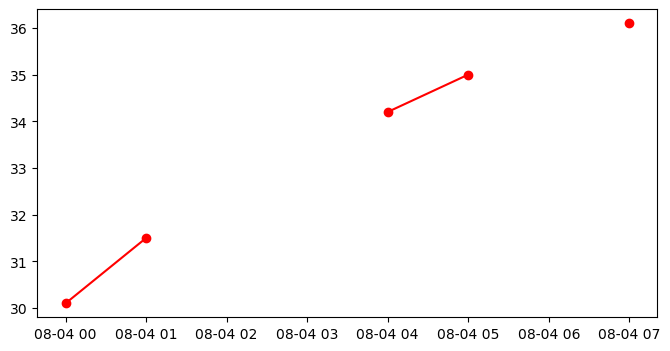

In [214]:
import matplotlib.pyplot as plt
# plotting sliniear
plt.figure(figsize=(8,4))
# I want to show the index which is of datetime format in the x axis of the graph plotted by pyplot I will have to use this df.index
plt.plot(dataFrame.index,dataFrame["temperature"],color="red",linestyle="-", marker="o",label="Original temperature data points with gaps (NaN values)")
plt.plot(dataFrame.index,dataFrame("slinear_interpolated_temperature"),color="green",linestyle="--",marker="o",label="Interploated temperature data using slinear method")
plt.title("Simualtion of hourly temperature readings with gaps")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

#### What just happen ? 
After inspecting the code I found out that I made a silly mistake here in this line ```plt.plot(dataFrame.index,dataFrame("slinear_interpolated_temperature"),color="green",linestyle="--",marker="o",label="Interploated temperature data using slinear method")``` <br>
Here I should have written this ```dataFrame["slinear_interpolated_temperature"]``` but instead I wrote this ```dataFrame("slinear_interpolated_temperature")```. <br>
I know I am stupid but hey thanks to my supidity atleast someone who is reading this notebook might avoid the mistake that I made. <br>

#### Analysis :
When I wrote this ```dataFrame("slinear_interpolated_temperature")``` I am essentially trying to call a dataFrame like a function which causes python to say : <br>
"You are treating a ```dataFrame``` object like a callable function but it's not a callable!" 

#### Lets fix the code and re-try plotting the interpolated data using slinear method once again

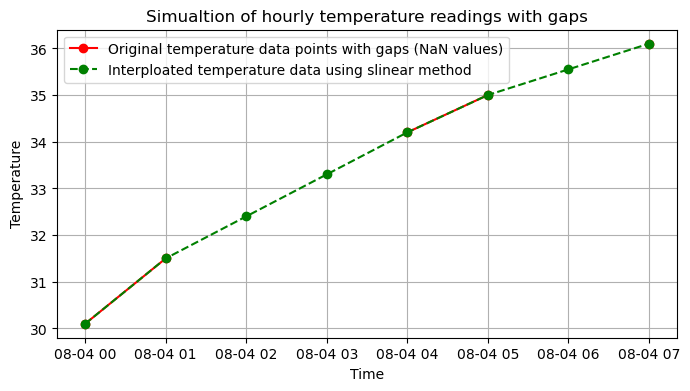

In [215]:
# plotting sliniear
plt.figure(figsize=(8,4))
# I want to show the index which is of datetime format in the x axis of the graph plotted by pyplot I will have to use this df.index
plt.plot(dataFrame.index,dataFrame["temperature"],color="red",linestyle="-", marker="o",label="Original temperature data points with gaps (NaN values)")
plt.plot(dataFrame.index,dataFrame["slinear_interpolated_temperature"],color="green",linestyle="--",marker="o",label="Interploated temperature data using slinear method")
plt.title("Simualtion of hourly temperature readings with gaps")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

### ```quadratic``` : Spline interpolation of order 2
Quadratic spline interpolation fits a second-degree polynomial (parabola) between known data points, rather than straight line (```linear```) or multiple connected lines (```piecewise linear```). This allows it to capture curvature in the data, making it useful for smooth accelerating or decelerating trends. <br>
Instead of drawing a straight lines between points (like in linear), it draws parabolic curves that gently follow the shape of the data. <br>
A quadratic function has the form : <br>
y = ax^2 + bx + c

#### Real world use cases : 
Example : Car acceleration <br>
Imagine you are tracking the distance traveled by a car every second. The car is accelerating , the distance increases faster and faster. <br>
| Time (s) | Distance (m) |
| -------- | ------------ |
| 0        | 0            |
| 1        | 3            |
| 2        | NaN          |
| 3        | 18           |


In [216]:
df = pd.DataFrame(
    {
        "time":[0,1,2,3],
        "distance":[0,3,np.nan,18]
    }
)
df

,time,distance
0,0,0.0
1,1,3.0
2,2,NaN
3,3,18.0


In [217]:
df["distance_quadratic"] = df["distance"].interpolate(method="quadratic")
df

,time,distance,distance_quadratic
0,0,0.0,0.0
1,1,3.0,3.0
2,2,NaN,9.0
3,3,18.0,18.0


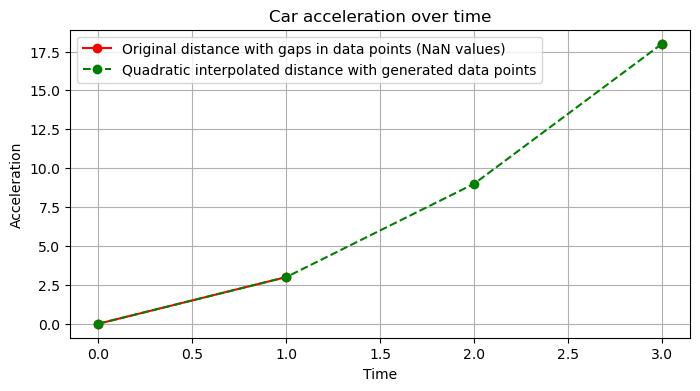

In [218]:
import matplotlib.pyplot as plt
# plotting quadratic 
plt.figure(figsize = (8,4))
plt.plot(df["time"],df["distance"],color="red",linestyle="-",marker="o",label="Original distance with gaps in data points (NaN values)")
plt.plot(df["time"],df["distance_quadratic"],color="green",linestyle="--",marker="o", label = "Quadratic interpolated distance with generated data points")
plt.title("Car acceleration over time")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.legend()
plt.grid(True)
plt.show()

#### When to use ```quadratic```:
- When data shows smooth but accelerate or decelerating behavior.
- Ideal for physics, motion tracking , growth models , sensor data with non-linear trends.
- More accurate than linear interpolation for curved data.

#### When not to use:
- If your data is noisy or fluctuates sharply. quadratic can overfit.
- If your data is truly linear. simpler methods like ```linear``` are better and more efficient.

### ```cubic``` : Spline interpolation of order 3
Cubic interpolation uses third-degree polynomials to connect data points. Each segment between two data points is modeled using a cubic equation : <br>
y = ax^3 + dx^2 + cx + d <br>
This method produces **smooth, continuous curves** with smooth transitions (first and seconds derivatives are continuous), making it especially useful for modeling natural or fluid motion. <br>
**(first and seconds derivatives are continuous) Explaiantion :** <br>
- First derivative: Measures the slope or rate of change.
  - In motion it represents velocity.
- Second derivative: Measures the change in slope.
  - In motion: It represents acceleration.

<br>

#### Why derivative continuity matters : 
Imagine drawing a smooth curve through data points, like tracking an object's movement: <br>
- Linear interpolation : Connects points with straight lines. The slope can suddenly jump at each point movement looks jerky.
- Cubic interpolation : Uses cubic polynomials between each pair of points and ensures:
  - No sharp corners (curve is smooth).
  - No sudden changes in velocity (first derivative is continuous).
  - No sudden changes in acceleration (second derivative is continuous)
- That means the motion appears fluid and natural , like the movement of a hand or a car.

#### What does that mean?
- ```linear``` : Straight lines between points (piecewise linear) (order 1)
- ```quadratic``` : parabolic curves (order 2)
- ```cubic``` :  more flexible curves, capturing subtle changes in trends direction or curvature.

#### Real world use cases :
Let's say you're tracking the hand position of a person drawing a circle, capture every few milliseconds. Because hand movement isn't jerkey, It's fluid and curved . A cubic interpolation gives a more natural fit to the motion. <br>
Example data:
| Time (s) | X Position |
| -------- | ---------- |
| 0        | 0          |
| 1        | 1          |
| 2        | NaN        |
| 3        | 1          |
| 4        | 0          | 

<br>

A ```'linear'``` or ```'quadratic'``` interpolation will make the curve look angular or not smooth enough. ```'cubic'``` smoothly interpolates the missing position at ```t=2```

In [219]:
df = pd.DataFrame({
    "time":[0,1,2,3,4],
    "x_pos":[0,1,np.nan,1,0]
})
df

,time,x_pos
0,0,0.0
1,1,1.0
2,2,NaN
3,3,1.0
4,4,0.0


In [220]:
df["x_pos"] = df["x_pos"].interpolate(method="cubic")
df

,time,x_pos
0,0,0.000000
1,1,1.000000
2,2,1.333333
3,3,1.000000
4,4,0.000000


#### Cubic interpolation Visual description : 
- Produces smooth S-shaped transitions
- Avoids sharp angles
- Allows for inflection points (where the curve bends direction)

#### When to use ```'cubic'```
- Data represents smooth, natural motions
- You want visually pleasing interpolation (example : animations, simulations)
- You need smooth first and second derivatives (important in physics and motion modeling)
- common domains :
  - Computer graphics and animation
  - sensor based tracking
  - climate and environmental modeling
  - audio signal smoothing

#### When to avoid:
- Not ideal for very noisy or discontinuous data
- Overkill for simple trends (linear or non-linear)
- More computationally expensive than linear/quadratic 

### Lets look at three more examples where cubic method interpolation can be used in real life

#### Example 1 : A robotic arm records its X, Y, Z coordinates every 0.5 seconds, but due to sensor lag, some positions are missing. Since robotic and human arm movements are fluid and continuous, cubic interpolation ensures smooth transitions between known positions.

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = [10, 12, np.nan, 15, np.nan, np.nan, 21, 23, np.nan, 28]
time = list(range(len(data)))

df = pd.DataFrame({"time":time,"position":data})
df

,time,position
0,0,10.0
1,1,12.0
2,2,NaN
3,3,15.0
4,4,NaN
5,5,NaN
6,6,21.0
7,7,23.0
8,8,NaN
9,9,28.0


In [222]:
# cubic interpolation
df["interpolated_position"] = df["position"].interpolate(method = "cubic")
df

,time,position,interpolated_position
0,0,10.0,10.000000
1,1,12.0,12.000000
2,2,NaN,13.508547
3,3,15.0,15.000000
4,4,NaN,16.833333
5,5,NaN,18.905983
6,6,21.0,21.000000
7,7,23.0,23.000000
8,8,NaN,25.200855
9,9,28.0,28.000000


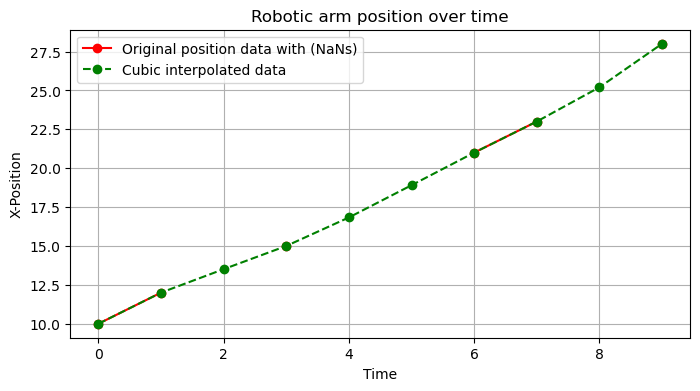

In [224]:
# plot position and interpolated_position
plt.figure(figsize = (8,4))
plt.plot(df["time"],df["position"], "ro-", label = "Original position data with (NaNs)")
plt.plot(df["time"],df["interpolated_position"],"g--o",label="Cubic interpolated data")
plt.title("Robotic arm position over time")
plt.xlabel("Time")
plt.ylabel("X-Position")
plt.legend()
plt.grid(True)
plt.show()

#### Why cubic interpolation?
- Prevents jerky motion.
- Preserves natural motion curves
- Useful in game development , robotics path planning and animation rigs

#### Code explaination:
- Breakdown of ```"ro-"```:
  - ```r``` -> red color
  - ```o``` -> circle markers at data points
  - ```-``` -> solid line
- So ```"ro-"``` plots:
  - A red solid line with circle markers at the data points.
- Breakdown of ```"g--o"```:
  - ```g``` -> green color
  - ```--``` -> dashed lines
  - ```o``` -> circle markers
- So, ```g--o``` plots:
  - A green dashed line with circle markers at the data points.

#### Other Examples:
| Format String | Description                            |
| ------------- | -------------------------------------- |
| `'b^--'`      | Blue dashed line with triangle markers |
| `'ks:'`       | Black dotted line with square markers  |
| `'m*-'`       | Magenta solid line with star markers   |

<br>

#### Alternative (Using ```color=```, ```linestyle=```, ```marker=```)
``` python
    plt.plot(df["time"], df["position"], color="red", linestyle="-", marker="o")
    plt.plot(df["time"], df["interpolated_position"], color="green", linestyle="--", marker="o")
```

#### Example 2: Simulated average monthly temperatures with missing entries

In [225]:
temperatures = [15.2, 16.8, np.nan, 20.1, 24.5, np.nan, np.nan, 26.2, 23.8, 20.0]
months = list(range(1, 11))
df = pd.DataFrame({"month":months,"temperature":temperatures})
df

,month,temperature
0,1,15.2
1,2,16.8
2,3,NaN
3,4,20.1
4,5,24.5
5,6,NaN
6,7,NaN
7,8,26.2
8,9,23.8
9,10,20.0


In [226]:
# interpolate data and handle NaN values using cubic method here
df["interpolated_temperature_data_using_cubic_method"] = df["temperature"].interpolate(method="cubic")
df

,month,temperature,interpolated_temperature_data_using_cubic_method
0,1,15.2,15.200000
1,2,16.8,16.800000
2,3,NaN,17.748067
3,4,20.1,20.100000
4,5,24.5,24.500000
5,6,NaN,27.126607
6,7,NaN,27.469726
7,8,26.2,26.200000
8,9,23.8,23.800000
9,10,20.0,20.000000


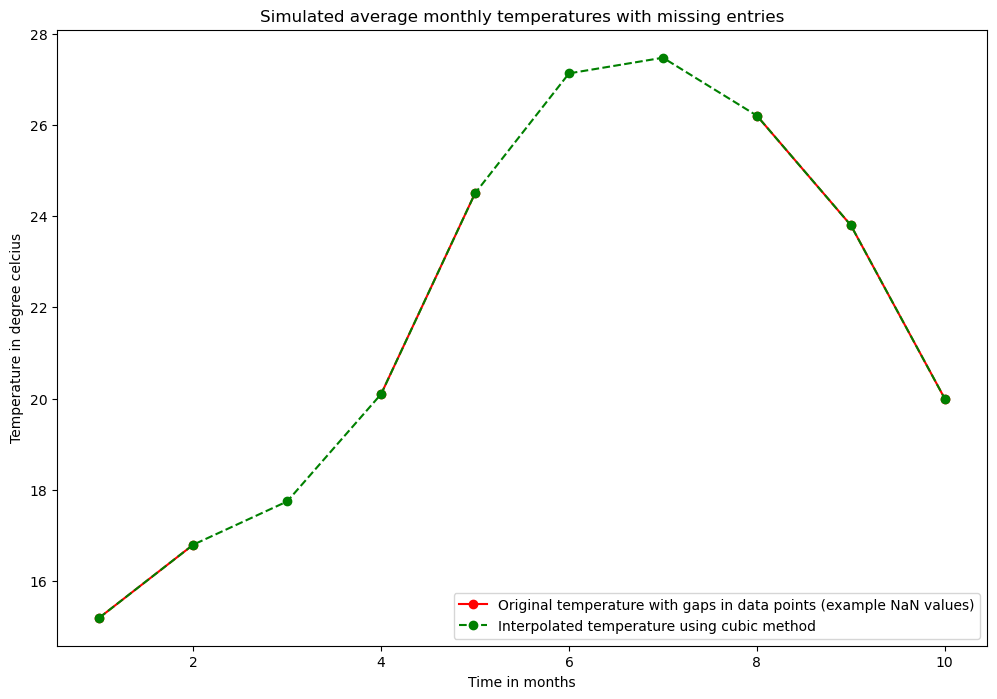

In [231]:
# Now plotting both original temperature data and interpolated data using cubic method in matplotlib
plt.figure(figsize=(12,8))
plt.plot(df["month"],df["temperature"],color="red",linestyle="-",marker="o",label="Original temperature with gaps in data points (example NaN values)")
plt.plot(df["month"],df["interpolated_temperature_data_using_cubic_method"],color="green",linestyle="--",marker="o",label="Interpolated temperature using cubic method")
plt.title("Simulated average monthly temperatures with missing entries")
plt.xlabel("Time in months")
plt.ylabel("Temperature in degree celcius")
plt.legend()
plt.show()

#### Example 3 : Simulated Audio Waveform Reconstruction

In [236]:
amplitude = [0.1, 0.4, np.nan, np.nan, -0.2, -0.5, np.nan, 0.0, 0.3, np.nan]
frames = list(range(10))

df = pd.DataFrame({'frame': frames, 'amplitude': amplitude})
df

,frame,amplitude
0,0,0.1
1,1,0.4
2,2,NaN
3,3,NaN
4,4,-0.2
5,5,-0.5
6,6,NaN
7,7,0.0
8,8,0.3
9,9,NaN


In [237]:
df["interpolated_amplitude_using_cubic_method"] = df["amplitude"].interpolate(method="cubic")
df

,frame,amplitude,interpolated_amplitude_using_cubic_method
0,0,0.1,0.100000
1,1,0.4,0.400000
2,2,NaN,0.387216
3,3,NaN,0.155824
4,4,-0.2,-0.200000
5,5,-0.5,-0.500000
6,6,NaN,-0.376081
7,7,0.0,0.000000
8,8,0.3,0.300000
9,9,NaN,NaN


#### Since interpolate function requires the atleast two data points for it to fill in the missing data points between those two points the last values has been left out as NaN. Hence its better to ignore the last row 
#### So I will be dropping the last row in favour of bettwe results.

In [238]:
df_dropped_last_row = df.drop(9)
df_dropped_last_row

,frame,amplitude,interpolated_amplitude_using_cubic_method
0,0,0.1,0.100000
1,1,0.4,0.400000
2,2,NaN,0.387216
3,3,NaN,0.155824
4,4,-0.2,-0.200000
5,5,-0.5,-0.500000
6,6,NaN,-0.376081
7,7,0.0,0.000000
8,8,0.3,0.300000


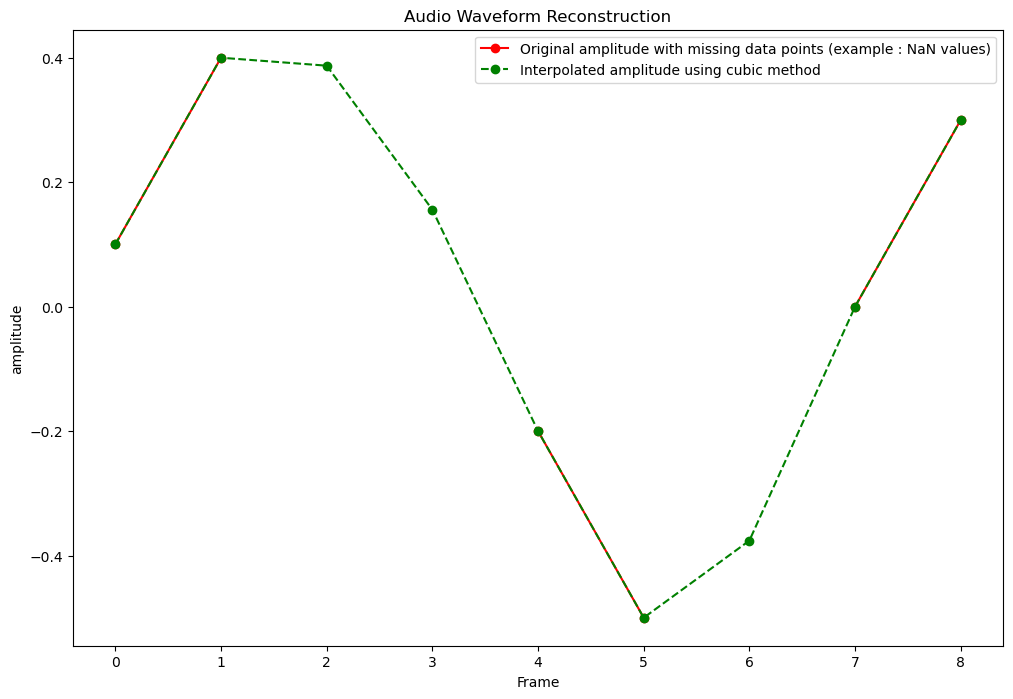

In [241]:
# Now plotting the amplitude along with interpolated_amplitude_using_cubic_method using matplotlib
plt.figure(figsize=(12,8))
plt.plot(df["frame"], df["amplitude"], color="red", linestyle="-",marker = "o", label="Original amplitude with missing data points (example : NaN values)")
plt.plot(df["frame"],df["interpolated_amplitude_using_cubic_method"], color="green", linestyle="--",marker="o",label="Interpolated amplitude using cubic method")
plt.title("Audio Waveform Reconstruction")
plt.xlabel("Frame")
plt.ylabel("amplitude")
plt.legend()
plt.show()

### Lets look at three more examples where nearest method interpolation can be used in real life
The nearest method replaces a missing value with the closest non-null value either before or after the missing entry (whichever is closer in position).

#### Real world example : Temperature sensor readings
Imagine if I am collecting temperature data every second from a sensor, but due to noise or disconnection, some values are missing. If your are only intrested in quick approximations (like in real-time monitoring), you might want to fill missing data with the nearest valid value.

In [243]:
temperature = [25.0, 25.1, np.nan, np.nan, 25.3, 25.4, np.nan, 25.6, np.nan, 25.9]
seconds = list(range(len(temperature)))

df = pd.DataFrame({"second":seconds, "temperature":temperature})
df

,second,temperature
0,0,25.0
1,1,25.1
2,2,NaN
3,3,NaN
4,4,25.3
5,5,25.4
6,6,NaN
7,7,25.6
8,8,NaN
9,9,25.9


In [247]:
df["nearest_interpolated_temperature"] = df["temperature"].interpolate(method="nearest")
df

,second,temperature,nearest_interpolated_temperature
0,0,25.0,25.0
1,1,25.1,25.1
2,2,NaN,25.1
3,3,NaN,25.3
4,4,25.3,25.3
5,5,25.4,25.4
6,6,NaN,25.4
7,7,25.6,25.6
8,8,NaN,25.6
9,9,25.9,25.9


#### Now plot the original temperature column and interpolated temperature column using matplotlib

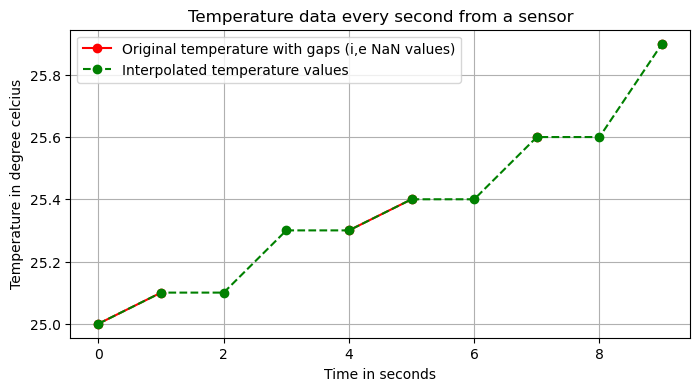

In [248]:
plt.figure(figsize = (8,4))
plt.plot(df["second"],df["temperature"],color="red",linestyle="-",marker="o",label="Original temperature with gaps (i,e NaN values)")
plt.plot(df["second"],df["nearest_interpolated_temperature"],color="green",linestyle="--",marker="o",label="Interpolated temperature values")
plt.title("Temperature data every second from a sensor")
plt.xlabel("Time in seconds")
plt.ylabel("Temperature in degree celcius")
plt.legend()
plt.grid()
plt.show()

### When to Use 'nearest'
| Situation                     | Why it's Good                                                                                      |
| ----------------------------- | -------------------------------------------------------------------------------------------------- |
| **Real-time dashboards**      | Fast, simple estimation — prioritizing speed over accuracy                                         |
| **Categorical/Discrete data** | Like filling in missing *class labels*, *ratings*, or *modes* where continuous trends don’t matter |
| **Quick fallback mechanism**  | When precision isn't critical but missing data breaks your system logic                            |

<br>

### When not to use nearest 
| Situation                  | Why It's Bad                                                                       |
| -------------------------- | ---------------------------------------------------------------------------------- |
| **Smooth/continuous data** | It can create **sudden jumps** or **step artifacts** in graphs or models           |
| **Scientific computation** | Inaccurate interpolations can skew results — better to use `'linear'` or `'cubic'` |
| **Predictive modeling**    | Introducing artificial flat zones can mislead machine learning models              |


### Lets look at three more examples where ```'barycentric'``` and ```'polynomial'``` method interpolation can be used in real life
Both 'barycentric' and 'polynomial' interpolation methods are based on polynomial interpolation, where a single polynomial is fitted through all the given data points.

#### What is Polynomial Interpolation?
Polynomial interpolation fits a single polynomial curve through all your data points. For ```n``` data points, the interpolating polynomial will be of degree ```n-1```.
- ```polynomial``` : Uses lagrange polynomial interpolation
- ```barycentric``` : A numerically stable variant of Lagrange interpolation (faster and more stable)

#### Important notes:
- Very flexible --- can pass exactly through known points.
- But risky --- overfitting , especially when data is noisy or there are many points (Runge's pehnomenon)

#### Real-World Example 1: Calibrating a Scientific Instrument
You have a limited number of calibration points for a scientific instrument (example : converting voltage readings to ph level). You can resume a perfect mathematical relationship between voltage and ph (no noise), so higher-order interpolation might be acceptable.

#### Why assuming 

## Sometimes there might be situation where I have to drop the rows with n.a. or NaN values 

In [52]:
# pc path
df_missing_values = pd.read_excel("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_missing_data_demo.xlsx")

# macbook path
# df_missing_values = pd.read_excel("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_missing_data_demo.xlsx", engine = "openpyxl")
df_missing_values 

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,1/10/2016,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


In [53]:
df_dropped_NaN = df_missing_values.dropna()
df_dropped_NaN

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
8,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
15,1/16/2016,47.0,37,70,29.52,8,7.0,0.24,7,Rain,340.0
16,1/17/2016,36.0,23,66,29.78,8,6.0,0.05,6,Fog-Snow,345.0
17,1/18/2016,25.0,6,53,29.83,9,12.0,T,2,Snow,293.0


#### As you can see all the rows containing NaN values have been removed

#### Suppose there is a situation where I have to drop all the rows that have all NaN values.

In [54]:
df_drop_rows_having_all_NaN = df_missing_values.dropna(how="all")
df_drop_rows_having_all_NaN

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,1/10/2016,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


#### If I want to keep the rows which have atleast one NaN value and drop every other rows.

In [55]:
df_keep_the_row_with_one_NaN_val = df_missing_values.dropna(thresh=1)
df_keep_the_row_with_one_NaN_val

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,1/10/2016,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


#### Now If I change the threshold to 10 then

In [56]:
df_keep_the_row_with_one_NaN_val = df_missing_values.dropna(thresh=10)
df_keep_the_row_with_one_NaN_val

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
6,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,1/10/2016,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0
11,1/12/2016,35.0,15,53,29.85,10,6.0,T,4,NaN,235.0
12,1/13/2016,26.0,4,42,29.94,10,10.0,0,0,NaN,284.0


#### Here thresh i.e threshold means the minimum amount of data that a row must have for it to be allowed to be white listed when .dropna() method is ran in pandas. 
- Basically It's saying that :
  - If there are 11 columns in the dataFrame
  - If there is a row where out of 11 columns 10 of them have values in it and 1 of them has a NaN value in it.
  - If ```df.dropna(thresh=10)``` where ```thresh=10``` then what it means is that all the rows that have 1 column with ```NaN``` value and 10 columns with data then It will not be dropped by ```.dropna()``` method. It will be allowed to be remained in the dataFrame after processing
  - All the other rows that do not fit in this rule defined in ```thresh``` will be dropped.

## Insert the missing date in the dataFrame where the date column is set to be the index of the dataFrame
Refer to this docs for more info : https://pandas.pydata.org/docs/reference/api/pandas.date_range.html

#### Set the EST which is essentially a date type column as an index of the dataFrame.
- Convert the EST column from string to date type column
- Then set the EST column as an index to the dataFrame

#### Verify if the EST column has the string type values stored in it

In [57]:
df_missing_values["EST"].apply(lambda x: isinstance (x,str)).all()

True

#### The result of this expression : ```df_missing_values["EST"].apply(lambda x: isinstance (x,str)).all()``` is returning True that means the values in EST column is in string format.

#### Convert the values in the EST column to be from string type to date type

In [58]:
df_missing_values["EST"] = pd.to_datetime(df_missing_values["EST"],format="%m/%d/%Y",errors="coerce")
df_missing_values

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,2016-01-01,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,2016-01-02,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,2016-01-03,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,2016-01-04,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,2016-01-05,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,2016-01-06,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,2016-01-07,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,2016-01-08,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,2016-01-09,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,2016-01-10,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


#### Let's check if all the values in the EST column is of type string

In [59]:
df_missing_values["EST"].apply(lambda x: isinstance(x,str)).all()

False

In [60]:
df_missing_values["EST"].dtype

dtype('<M8[ns]')

#### The result is False hence the EST column values are not of type string i.e they have been successfully converted to datetime object in this dataFrame 

#### Now we can safely set the EST column as index of this dataFrame

In [61]:
df_missing_values.set_index(df_missing_values["EST"],inplace=True)
df_missing_values

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,,
2016-01-01,2016-01-01,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
2016-01-02,2016-01-02,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2016-01-03,2016-01-03,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
2016-01-04,2016-01-04,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
2016-01-05,2016-01-05,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
2016-01-06,2016-01-06,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
2016-01-07,2016-01-07,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
2016-01-08,2016-01-08,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
2016-01-09,2016-01-09,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0


#### Now that the EST column has been set I don't need EST column which makes it redundant 

In [62]:
df_EST_index = df_missing_values.drop("EST",axis=1)
df_EST_index

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,
2016-01-01,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
2016-01-02,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2016-01-03,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
2016-01-04,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
2016-01-05,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
2016-01-06,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
2016-01-07,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
2016-01-08,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
2016-01-09,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0


## Adding missing dates in the dataFrame where EST (date type column) is set as an index in the dataFrame

#### Since I don't have any missing date values in the dataFrame I will manually have to drop the rows from the dataFrame

In [63]:
df_dropped_dates = df_EST_index.drop(df_EST_index.index[["2016-01-03", "2016-01-08"	, "2016-01-09"]])
df_dropped_dates

IndexError: arrays used as indices must be of integer or boolean type

#### Explaination
- ```df_dropped_dates = df_EST_index.drop(df_EST_index.index[["2016-01-03", "2016-01-08", "2016-01-09"]])```
- This causes an error ```because df_EST_index.index[...]``` expects integer or boolean indexing, not string labels like ```"2016-01-03"```.
- ```df_EST_index.index[...]``` is trying to index the index using a list of strings, which is not allowed — it's not integer-based or boolean-based indexing.
- Instead, I was trying to remove rows by label, not by position.
#### solution
- During my search I found out that I can pass those dates strings directly to ```.drop()``` without using ```df_EST_index.index[...].```.
- This works because ```drop``` can take labels (as strings) if the index is of ```datetime64``` type — and Pandas will internally convert your strings to datetimes and match them correctly.

In [64]:
# This code worked fine on my pc but its not working on my macbook for some reason
# df_dropped_dates = df_EST_index.drop(["2016-01-03", "2016-01-08", "2016-01-09"])
# df_dropped_dates

# writing this code to make it work on older version of pandas
dates_to_drop = pd.to_datetime(["2016-01-03", "2016-01-08", "2016-01-09"])
df_dropped_dates = df_EST_index.drop(dates_to_drop)
df_dropped_dates

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,
2016-01-01,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
2016-01-02,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2016-01-04,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
2016-01-05,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
2016-01-06,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
2016-01-07,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
2016-01-10,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0
2016-01-11,33.0,8,37,29.92,10,NaN,0,1,NaN,289.0
2016-01-12,35.0,15,53,29.85,10,6.0,T,4,NaN,235.0


#### Now what I have got the dataFrame that simulates the missing dates that I may get in the real world I can move forward.

#### Adding missing dates in the dataFrame where EST (date type column) is set as an index in the dataFrame

In [65]:
dt = pd.date_range("2016-01-01", "2016-01-31")
idx = pd.DatetimeIndex(dt)
df_dropped_dates.reindex(idx)

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
2016-01-01,38.0,23.0,52.0,30.03,10.0,8.0,0,5.0,NaN,281.0
2016-01-02,36.0,18.0,46.0,30.02,10.0,7.0,0,3.0,NaN,275.0
2016-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-04,25.0,9.0,44.0,30.05,10.0,9.0,0,3.0,NaN,345.0
2016-01-05,NaN,-3.0,41.0,30.57,10.0,5.0,0,0.0,NaN,333.0
2016-01-06,33.0,4.0,35.0,30.50,10.0,4.0,0,0.0,NaN,NaN
2016-01-07,39.0,11.0,33.0,30.28,10.0,2.0,0,3.0,NaN,293.0
2016-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-10,50.0,46.0,71.0,29.59,4.0,NaN,1.8,7.0,Rain,109.0


#### As you can see that the missing dates have been added in the dataFrame with all the values as NaN

#### Now I will have to use interpolation to fill all the NaN values based on dates using time method 

In [66]:
# replace NaN with 0
# convert the string type numbers into integer type numbers 
# This code works on newer version of pandas 
# df_dropped_dates.infer_objects(copy=False)

# This code will work on older version of pandas
df_dropped_dates.infer_objects()

# only select those columns whose data-type is of type number and then interpolate using time method
df_interpolate_using_time = df_dropped_dates.select_dtypes(include=["number"]).interpolate(method="time",limit_direction="both")
df_interpolate_using_time

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,CloudCover,WindDirDegrees
EST,,,,,,,,
2016-01-01,38.00,23,52,30.03,10,8.0,5,281.0
2016-01-02,36.00,18,46,30.02,10,7.0,3,275.0
2016-01-04,25.00,9,44,30.05,10,9.0,3,345.0
2016-01-05,29.00,-3,41,30.57,10,5.0,0,333.0
2016-01-06,33.00,4,35,30.50,10,4.0,0,313.0
2016-01-07,39.00,11,33,30.28,10,2.0,3,293.0
2016-01-10,50.00,46,71,29.59,4,4.4,7,109.0
2016-01-11,33.00,8,37,29.92,10,5.2,1,289.0
2016-01-12,35.00,15,53,29.85,10,6.0,4,235.0


### What gives why is interpolation dropping the rows which have NaN values in all of their columns ?
#### Explanation:
- Pandas’ interpolation methods (like "time", "linear", etc.) require at least some non-NaN values to interpolate across.
- If a row has all columns as NaN, pandas has no basis to infer values — so it skips interpolation for that row.

## Handle missing data using Replace function 

In [67]:
import numpy as np
import pandas as pd
# pc path
df_missing_data = pd.read_excel("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_missing_data_demo.xlsx")

# macbook path
# df_missing_data = pd.read_excel("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_missing_data_demo.xlsx", engine="openpyxl")
df_missing_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,1/2/2016,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,1/3/2016,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,1/4/2016,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,1/5/2016,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,1/6/2016,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,1/7/2016,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,1/8/2016,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,1/9/2016,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,1/10/2016,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


#### Make EST a date column the index of the dataFrame

#### Lets check if EST is a of string type column

In [68]:
df_missing_data["EST"].apply(lambda x: isinstance(x,str)).all()

True

#### This goes to show that the EST column contains date in string dataType form

#### Convert the EST column values into a datetime type values

In [69]:
df_missing_data["EST"] = pd.to_datetime(df_missing_data["EST"],format="%m/%d/%Y",errors="coerce")
df_missing_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,2016-01-01,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
1,2016-01-02,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2,2016-01-03,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
3,2016-01-04,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
4,2016-01-05,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
5,2016-01-06,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
6,2016-01-07,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
7,2016-01-08,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
8,2016-01-09,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0
9,2016-01-10,50.0,46,71,29.59,4,NaN,1.8,7,Rain,109.0


#### Set the EST as index in the dataFrame

In [70]:
df_missing_data.set_index("EST",inplace=True)
df_missing_data

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,
2016-01-01,38.0,23,52,30.03,10,8.0,0,5,NaN,281.0
2016-01-02,36.0,18,46,30.02,10,7.0,0,3,NaN,275.0
2016-01-03,40.0,21,47,29.86,10,8.0,0,1,NaN,277.0
2016-01-04,25.0,9,44,30.05,10,9.0,0,3,NaN,345.0
2016-01-05,NaN,-3,41,30.57,10,5.0,0,0,NaN,333.0
2016-01-06,33.0,4,35,30.50,10,4.0,0,0,NaN,NaN
2016-01-07,39.0,11,33,30.28,10,2.0,0,3,NaN,293.0
2016-01-08,39.0,29,64,30.20,10,4.0,0,8,NaN,79.0
2016-01-09,44.0,38,77,30.16,9,8.0,T,8,Rain,76.0


## Use replace function to -ve values as NaN in the dataFrame
- This is just to test what replace function does.
- This replace fuction do not make changes in the original dataFrame but It creates a copy of the original dataFrame with changes in it after the operation is complete.

In [71]:
replaced_df=df_missing_data.replace(-3,np.NaN)
replaced_df

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,
2016-01-01,38.0,23.0,52,30.03,10,8.0,0,5,NaN,281.0
2016-01-02,36.0,18.0,46,30.02,10,7.0,0,3,NaN,275.0
2016-01-03,40.0,21.0,47,29.86,10,8.0,0,1,NaN,277.0
2016-01-04,25.0,9.0,44,30.05,10,9.0,0,3,NaN,345.0
2016-01-05,NaN,NaN,41,30.57,10,5.0,0,0,NaN,333.0
2016-01-06,33.0,4.0,35,30.50,10,4.0,0,0,NaN,NaN
2016-01-07,39.0,11.0,33,30.28,10,2.0,0,3,NaN,293.0
2016-01-08,39.0,29.0,64,30.20,10,4.0,0,8,NaN,79.0
2016-01-09,44.0,38.0,77,30.16,9,8.0,T,8,Rain,76.0


#### lets replace NaN values in Events column with 0 using replace function

In [72]:
replaced_df["Events"] = replaced_df["Events"].replace(np.NaN,0)
replaced_df

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,
2016-01-01,38.0,23.0,52,30.03,10,8.0,0,5,0,281.0
2016-01-02,36.0,18.0,46,30.02,10,7.0,0,3,0,275.0
2016-01-03,40.0,21.0,47,29.86,10,8.0,0,1,0,277.0
2016-01-04,25.0,9.0,44,30.05,10,9.0,0,3,0,345.0
2016-01-05,NaN,NaN,41,30.57,10,5.0,0,0,0,333.0
2016-01-06,33.0,4.0,35,30.50,10,4.0,0,0,0,NaN
2016-01-07,39.0,11.0,33,30.28,10,2.0,0,3,0,293.0
2016-01-08,39.0,29.0,64,30.20,10,4.0,0,8,0,79.0
2016-01-09,44.0,38.0,77,30.16,9,8.0,T,8,Rain,76.0


#### How to replace values in multiple columns using replace function
- I have chosen ```WindDirDegrees``` column for this demo. Since I have NaN values in it I am going to replace it with negative random number ```-989``` for this demo.

In [73]:
replaced_df["WindDirDegrees"] = replaced_df["WindDirDegrees"].replace(np.NaN,-989)
replaced_df

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,
2016-01-01,38.0,23.0,52,30.03,10,8.0,0,5,0,281.0
2016-01-02,36.0,18.0,46,30.02,10,7.0,0,3,0,275.0
2016-01-03,40.0,21.0,47,29.86,10,8.0,0,1,0,277.0
2016-01-04,25.0,9.0,44,30.05,10,9.0,0,3,0,345.0
2016-01-05,NaN,NaN,41,30.57,10,5.0,0,0,0,333.0
2016-01-06,33.0,4.0,35,30.50,10,4.0,0,0,0,-989.0
2016-01-07,39.0,11.0,33,30.28,10,2.0,0,3,0,293.0
2016-01-08,39.0,29.0,64,30.20,10,4.0,0,8,0,79.0
2016-01-09,44.0,38.0,77,30.16,9,8.0,T,8,Rain,76.0


### Now I can use .replace function with a dictionary to see if I can replace values using this function in multiple columns of the dataFrame

In [74]:
replaced_df = replaced_df.replace({
    "Events" : 0,
    "WindDirDegrees": -989.0
},np.NaN)
replaced_df

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
EST,,,,,,,,,,
2016-01-01,38.0,23.0,52,30.03,10,8.0,0,5,NaN,281.0
2016-01-02,36.0,18.0,46,30.02,10,7.0,0,3,NaN,275.0
2016-01-03,40.0,21.0,47,29.86,10,8.0,0,1,NaN,277.0
2016-01-04,25.0,9.0,44,30.05,10,9.0,0,3,NaN,345.0
2016-01-05,NaN,NaN,41,30.57,10,5.0,0,0,NaN,333.0
2016-01-06,33.0,4.0,35,30.50,10,4.0,0,0,NaN,NaN
2016-01-07,39.0,11.0,33,30.28,10,2.0,0,3,NaN,293.0
2016-01-08,39.0,29.0,64,30.20,10,4.0,0,8,NaN,79.0
2016-01-09,44.0,38.0,77,30.16,9,8.0,T,8,Rain,76.0


### Lets perform interpolation using time method just for fun shall we ?

In [75]:
# convert all the values in the columns in numeric type
# This code works on newer version of pandas
replaced_df.infer_objects(copy=False)
# replaced_df.infer_objects()

# perform interpolation using time method on the dataFrame
interpolated_df = replaced_df.select_dtypes(include=["number"]).interpolate(method="time")
interpolated_df

,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,CloudCover,WindDirDegrees
EST,,,,,,,,
2016-01-01,38.00,23.0,52,30.03,10,8.000000,5,281.0
2016-01-02,36.00,18.0,46,30.02,10,7.000000,3,275.0
2016-01-03,40.00,21.0,47,29.86,10,8.000000,1,277.0
2016-01-04,25.00,9.0,44,30.05,10,9.000000,3,345.0
2016-01-05,29.00,6.5,41,30.57,10,5.000000,0,333.0
2016-01-06,33.00,4.0,35,30.50,10,4.000000,0,313.0
2016-01-07,39.00,11.0,33,30.28,10,2.000000,3,293.0
2016-01-08,39.00,29.0,64,30.20,10,4.000000,8,79.0
2016-01-09,44.00,38.0,77,30.16,9,8.000000,8,76.0


## How to handle data where differnt types of measurement metrics are found in the same column
- Example : 
  - Temperature column may have temperature in degree celcius and in Farenhite both
  - Windspeed column may have speed of the wind in mph and kph both.

In [76]:
# pc path
df_missing_data = pd.read_excel("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_different_measurement_type_demo.xlsx")

# macbook path
# df_missing_data = pd.read_excel("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather_different_measurement_type_demo.xlsx", engine="openpyxl")
df_missing_data

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38 F,23,52,30.03,10,8 mph,0,5,NaN,281.0
1,1/2/2016,36 F,18,46,30.02,10,7 kph,0,3,NaN,275.0
2,1/3/2016,40,21,47,29.86,10,8,0,1,NaN,277.0
3,1/4/2016,25,9,44,30.05,10,9 kph,0,3,NaN,345.0
4,1/5/2016,NaN,-3,41,30.57,10,5,0,0,NaN,333.0
5,1/6/2016,33 C,4,35,30.50,10,4 mph,0,0,NaN,NaN
6,1/7/2016,39 C,11,33,30.28,10,2,0,3,NaN,293.0
7,1/8/2016,39,29,64,30.20,10,4,0,8,NaN,79.0
8,1/9/2016,44,38,77,30.16,9,8,T,8,Rain,76.0
9,1/10/2016,50,46,71,29.59,4,NaN,1.8,7,Rain,109.0


#### Now these types of situations are very tricky to solve because
- I have to remove the Farenhite ```F``` and Celcius ```C``` from the temperature column.
- Similarly I will have to remove ```mph``` and ```kph``` from the WindSpeedMPH column.

#### The best way to handle this is to use a regex

In [77]:
#### The best way to handle this is to use a regex
start video from here https://youtu.be/XOxABiMhG2U?list=PLeo1K3hjS3uuASpe-1LjfG5f14Bnozjwy&t=511

SyntaxError: invalid decimal literal (3978432810.py, line 2)